# CX-Level — CX Density & Threshold Adherence Figures

Generates two thesis-ready figures:
1. **CX density comparison** — mean cx_ratio and mean n_cx per condition per qubit count.
2. **Threshold adherence** — distribution of generated cx_ratio per condition overlaid on the
   low/medium/high zone boundaries from the training data.

Circuits are generated at `max_gates=52` to match the training data format in which
the cx_level tertile thresholds were defined.


In [1]:
import os, sys, random, ast
from collections import defaultdict
from pathlib import Path

import hydra
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import torch
from hydra.core.global_hydra import GlobalHydra

from notebooks.shared.bootstrap import setup_notebook_paths
PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import make_artifact_dir, save_figure, save_pickle, save_json
from quantum_diffusion.evaluation.evaluator import SRVEvaluator
from my_genQC.inference.sampling import generate_tensors as _generate_tensors


In [2]:
# -- Config --------------------------------------------------------------------
DATASET_BASE       = "./artifacts/datasets/srv-datasets/quditkit"
TRAIN_DS_PATH      = "./artifacts/datasets/qc_srv_dataset_3to8qubit/dataset"
QUBIT_COUNTS       = [3, 4, 5, 6, 7, 8]
SEED               = 1234
GUIDANCE_SCALE     = 7.5
N_SAMPLES          = 256    # per (qubit_count, condition)
MAX_GATES_CX       = 52     # match training data (where tertiles were computed)

TRUE_BASELINE_MODEL = "./artifacts/models/srv-baseline-reproduction/paper_stage_2"
FINETUNED_MODEL     = "./artifacts/models/srv-noise-conditioning/srv_noise_finetuned"

CX_LEVELS  = ["low", "medium", "high"]
CONDITIONS = ["true_baseline"] + CX_LEVELS

COND_COLORS  = {"true_baseline": "#4878D0", "low": "#EE854A", "medium": "#6ACC65", "high": "#D65F5F"}
COND_LABELS  = {"true_baseline": "baseline", "low": "cx_level=low",
                "medium": "cx_level=medium", "high": "cx_level=high"}

ARTIFACT_SUBDIR = "srv-noise-conditioning"
RUN_NAME        = "cx_ratio_analysis"
ARTIFACT_DIR    = make_artifact_dir(PROJECT_ROOT, ARTIFACT_SUBDIR, RUN_NAME)
print(f"Saving to: {ARTIFACT_DIR}")


Saving to: /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/srv-noise-conditioning/cx_ratio_analysis


In [3]:
# -- Threshold computation from training data ----------------------------------
# Training data was generated at max_gates=52; tertiles were computed on that.

print("Loading training data...")
x_tr = torch.load(f"{TRAIN_DS_PATH}/ds_x.pt", map_location="cpu", weights_only=False)["0"]
y_tr = torch.load(f"{TRAIN_DS_PATH}/ds_y.pt", map_location="cpu", weights_only=False)

n_cx_tr = ((x_tr == -2) | (x_tr == 2)).any(dim=1).sum(dim=1).float().numpy()
ng_tr   = (x_tr != 3).any(dim=1).sum(dim=1).float().numpy()
ng_tr   = np.where(ng_tr > 0, ng_tr, 1.0)
cx_ratio_tr = n_cx_tr / ng_tr

def _parse_qcount(lbl):
    s = str(lbl).strip()
    if not s or "[" not in s:
        return None
    try:
        return len(ast.literal_eval(s[s.find("["):s.find("]")+1]))
    except Exception:
        return None

tr_qcounts = np.array([_parse_qcount(l) for l in y_tr], dtype=object)

thresholds = {}
for q in QUBIT_COUNTS:
    mask = tr_qcounts == q
    if not mask.any():
        continue
    r = cx_ratio_tr[mask]
    thresholds[q] = dict(t33=float(np.percentile(r, 33.33)),
                          t67=float(np.percentile(r, 66.67)),
                          mean=float(r.mean()))

T33_GLOBAL = float(np.percentile(cx_ratio_tr, 33.33))
T67_GLOBAL = float(np.percentile(cx_ratio_tr, 66.67))

print(f"Global thresholds: t33={T33_GLOBAL:.3f}  t67={T67_GLOBAL:.3f}")
print("Per-qubit thresholds:")
for q, v in thresholds.items():
    print(f"  {q}q  t33={v['t33']:.3f}  t67={v['t67']:.3f}  mean={v['mean']:.3f}")


Loading training data...


Global thresholds: t33=0.583  t67=0.667
Per-qubit thresholds:


In [4]:

# -- Helper functions ----------------------------------------------------------

def _build_cfg(dataset_path, model_dir, num_samples):
    GlobalHydra.instance().clear()
    abs_conf = str(Path(PROJECT_ROOT) / "conf")
    with hydra.initialize_config_dir(version_base=None, config_dir=abs_conf):
        cfg = hydra.compose(
            config_name="config.yaml",
            overrides=["evaluation=paper_srv",
                       f"evaluation.model_params.guidance_scale={GUIDANCE_SCALE}"],
        )
    cfg = cfg["evaluation"]
    cfg.dataset     = str(Path(dataset_path).expanduser().resolve())
    cfg.model_dir   = str(Path(model_dir).expanduser().resolve())
    cfg.hf_repo     = None
    cfg.num_samples = int(num_samples)
    cfg.max_gates   = 16
    cfg.save_output = False
    cfg.wandb.enable = False
    return cfg


def load_prompts_stratified(q, n, seed):
    raw = torch.load(f"{DATASET_BASE}/srv_{q}q_dataset/dataset/ds_y.pt",
                     map_location="cpu", weights_only=False)
    # ds_y.pt is stored as {'0': numpy_array_of_strings}
    arr = raw["0"] if isinstance(raw, dict) else raw
    labels = [str(l) for l in arr]
    rng = random.Random(seed)
    bucket_idx = defaultdict(list)
    for i, l in enumerate(labels):
        try:
            srv = ast.literal_eval(l[l.find("["):l.find("]")+1])
            bucket_idx[sum(1 for v in srv if v == 2)].append(i)
        except Exception:
            continue
    idx = []
    per_bucket = max(1, n // max(len(bucket_idx), 1))
    for b in sorted(bucket_idx):
        pool = bucket_idx[b]
        idx.extend(rng.sample(pool, min(per_bucket, len(pool))))
    random.Random(seed).shuffle(idx)
    return [labels[i] for i in idx[:n]]


def measure_cx_ratio(tensors):
    t = tensors.cpu()
    n_cx = ((t == -2) | (t == 2)).any(dim=1).sum(dim=1).float().numpy()
    ng   = (t != 3).any(dim=1).sum(dim=1).float().numpy()
    ng   = np.where(ng > 0, ng, 1.0)
    return n_cx, n_cx / ng


In [5]:
# -- Load models (once, reuse across qubit counts) -----------------------------
print("Loading models...")
ds_3q = f"{DATASET_BASE}/srv_3q_dataset"

cfg_base     = _build_cfg(ds_3q, TRUE_BASELINE_MODEL, N_SAMPLES * 3)
eval_base    = SRVEvaluator(config=cfg_base)
pipeline_base = eval_base.pipeline
auto_batch   = cfg_base.model_params.auto_batch_size

cfg_ft       = _build_cfg(ds_3q, FINETUNED_MODEL, N_SAMPLES * 3)
eval_ft      = SRVEvaluator(config=cfg_ft)
pipeline_ft  = eval_ft.pipeline

print("Models loaded.")


Loading models...
[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
2026-05-28 12:19:50 - quantum_diffusion.evaluation.evaluator - INFO - Running w/o wandb


2026-05-28 12:19:50 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_x.safetensors` onto device: cuda.


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-28 12:19:51 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset


[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/srv-baseline-reproduction/paper_stage_2/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet`. Freeze model: True


...

2026-05-28 12:19:59 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_x.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-28 12:19:59 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset


[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/srv-noise-conditioning/srv_noise_finetuned/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet`. Freeze model: True


[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True


[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/srv-noise-conditioning/srv_noise_finetuned/embedder.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet`. Freeze model: True
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...
Models loaded.


In [6]:

# -- Generate circuits & measure cx_ratio at max_gates=52 ----------------------
cx_data = {cond: {} for cond in CONDITIONS}

for q in QUBIT_COUNTS:
    print(f"\n{q}q")
    prompts = load_prompts_stratified(q, N_SAMPLES, SEED)
    n = len(prompts)
    print(f"  loaded {n} prompts")

    gen_kw = dict(samples=n, system_size=q, num_of_qubits=q,
                  max_gates=MAX_GATES_CX, g=GUIDANCE_SCALE,
                  auto_batch_size=auto_batch, enable_params=False, no_bar=True)

    # true_baseline — also use first batch to sanity-check tensor encoding
    t = _generate_tensors(pipeline=pipeline_base, prompt=prompts, **gen_kw)
    if q == 3:
        t_cpu = t.cpu()
        uniq = t_cpu[0].unique().tolist()
        print(f"  [sanity] tensor unique values (circuit 0): {uniq[:10]}")
    n_cx, ratio = measure_cx_ratio(t)
    cx_data["true_baseline"][q] = {"n_cx": n_cx, "cx_ratio": ratio}
    print(f"  true_baseline  cx_ratio={ratio.mean():.3f}  n_cx={n_cx.mean():.1f}")

    # cx_level conditions
    for level in CX_LEVELS:
        suffixed = [p + f"; cx_level={level}" for p in prompts]
        t = _generate_tensors(pipeline=pipeline_ft, prompt=suffixed, **gen_kw)
        n_cx, ratio = measure_cx_ratio(t)
        cx_data[level][q] = {"n_cx": n_cx, "cx_ratio": ratio}
        print(f"  cx_level={level}  cx_ratio={ratio.mean():.3f}  n_cx={n_cx.mean():.1f}")

print("\nGeneration done.")
save_pickle(cx_data, ARTIFACT_DIR / "cx_ratio_data.pkl")



3q


  loaded 255 prompts


  [sanity] tensor unique values (circuit 0): [-2, 0, 2, 3]
  true_baseline  cx_ratio=0.769  n_cx=11.4


  cx_level=low  cx_ratio=0.429  n_cx=5.9


  cx_level=medium  cx_ratio=0.657  n_cx=9.5


...

  true_baseline  cx_ratio=0.612  n_cx=15.8


  cx_level=low  cx_ratio=0.439  n_cx=10.2


  cx_level=medium  cx_ratio=0.625  n_cx=22.7


  cx_level=high  cx_ratio=0.775  n_cx=15.9

Generation done.


PosixPath('/home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/srv-noise-conditioning/cx_ratio_analysis/cx_ratio_data.pkl')

## Figure 1 — CX Density Comparison


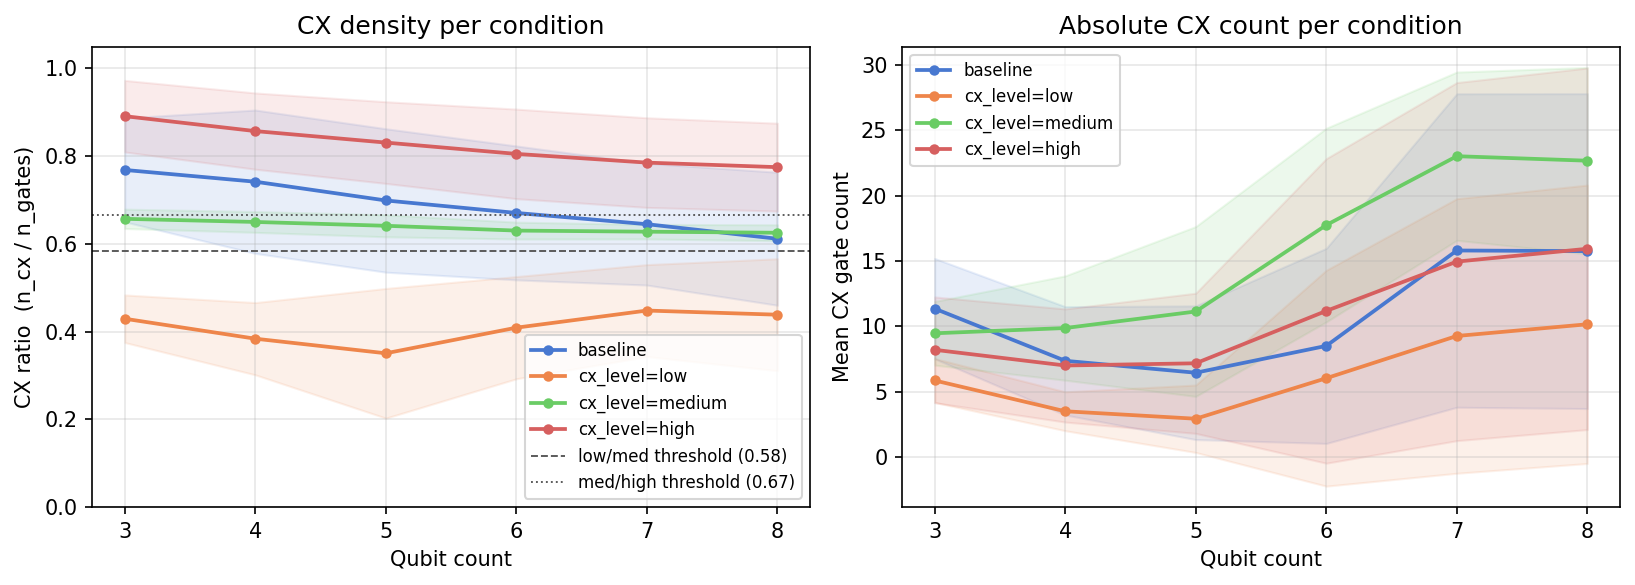

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=150)

for cond in CONDITIONS:
    qs  = sorted(cx_data[cond].keys())
    mr  = np.array([cx_data[cond][q]["cx_ratio"].mean() for q in qs])
    sr  = np.array([cx_data[cond][q]["cx_ratio"].std()  for q in qs])
    mn  = np.array([cx_data[cond][q]["n_cx"].mean()     for q in qs])
    sn  = np.array([cx_data[cond][q]["n_cx"].std()      for q in qs])
    c   = COND_COLORS[cond]
    lbl = COND_LABELS[cond]

    axes[0].plot(qs, mr, marker="o", linewidth=1.8, markersize=4, color=c, label=lbl)
    axes[0].fill_between(qs, mr - sr, mr + sr, alpha=0.12, color=c)

    axes[1].plot(qs, mn, marker="o", linewidth=1.8, markersize=4, color=c, label=lbl)
    axes[1].fill_between(qs, mn - sn, mn + sn, alpha=0.12, color=c)

# Threshold reference lines on cx_ratio panel
axes[0].axhline(T33_GLOBAL, color="#555", linestyle="--", linewidth=0.9,
                label=f"low/med threshold ({T33_GLOBAL:.2f})")
axes[0].axhline(T67_GLOBAL, color="#555", linestyle=":",  linewidth=0.9,
                label=f"med/high threshold ({T67_GLOBAL:.2f})")

for ax, ylabel, title in zip(
    axes,
    ["CX ratio  (n_cx / n_gates)", "Mean CX gate count"],
    ["CX density per condition", "Absolute CX count per condition"],
):
    ax.set_xlabel("Qubit count")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(QUBIT_COUNTS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylim(0, 1.05)

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "cx_density_comparison.png")
plt.show()


## Figure 2 — Threshold Adherence

Box plots of generated cx_ratio per condition per qubit count, overlaid on the low/medium/high
zone boundaries derived from the training data (global t33 and t67).


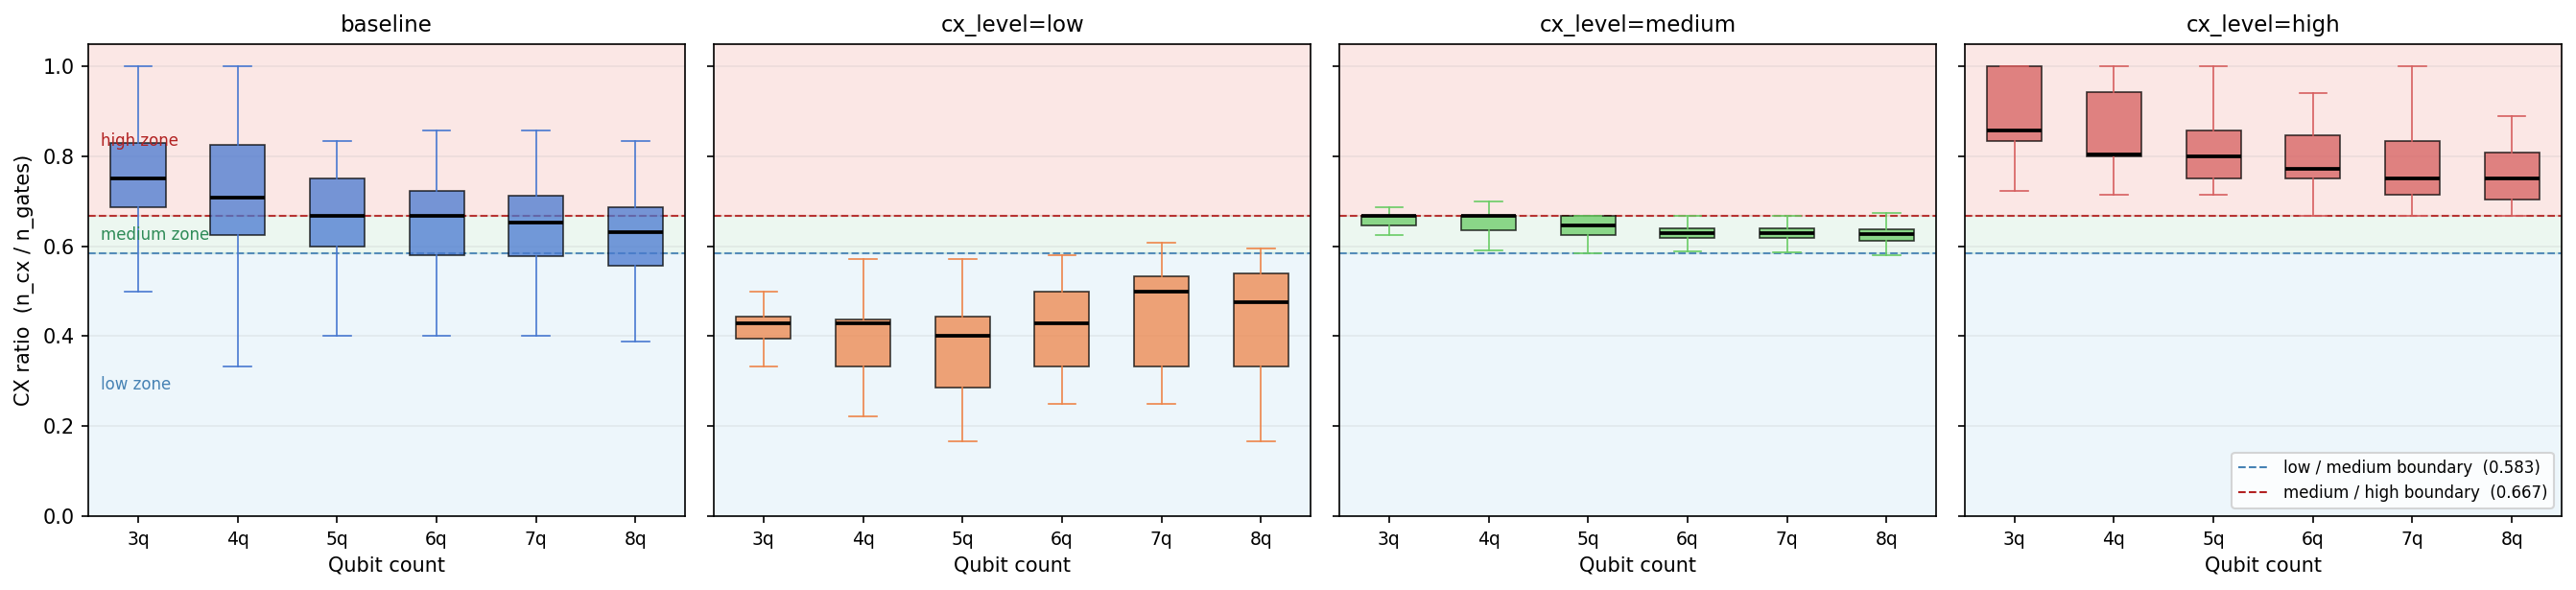

In [8]:
ZONE_COLORS = {"low": "#AED6F1", "medium": "#A9DFBF", "high": "#F1948A"}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), dpi=150, sharey=True)

for ax, cond in zip(axes, CONDITIONS):
    # Zone shading
    ax.axhspan(0,           T33_GLOBAL, color=ZONE_COLORS["low"],    alpha=0.22)
    ax.axhspan(T33_GLOBAL,  T67_GLOBAL, color=ZONE_COLORS["medium"], alpha=0.22)
    ax.axhspan(T67_GLOBAL,  1.05,       color=ZONE_COLORS["high"],   alpha=0.22)

    # Threshold lines
    ax.axhline(T33_GLOBAL, color="steelblue", linestyle="--", linewidth=1.0, alpha=0.9)
    ax.axhline(T67_GLOBAL, color="firebrick", linestyle="--", linewidth=1.0, alpha=0.9)

    qs       = sorted(cx_data[cond].keys())
    positions = list(range(len(qs)))
    data      = [cx_data[cond][q]["cx_ratio"] for q in qs]

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.8),
        boxprops=dict(facecolor=COND_COLORS[cond], alpha=0.75, linewidth=0.8),
        whiskerprops=dict(color=COND_COLORS[cond], linewidth=0.8),
        capprops=dict(color=COND_COLORS[cond], linewidth=0.8),
    )

    ax.set_xticks(positions)
    ax.set_xticklabels([f"{q}q" for q in qs], fontsize=9)
    ax.set_xlabel("Qubit count")
    ax.set_title(COND_LABELS[cond], fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.2, axis="y")

axes[0].set_ylabel("CX ratio  (n_cx / n_gates)")

# Zone labels on leftmost panel
trans = axes[0].get_yaxis_transform()
axes[0].text(0.02, T33_GLOBAL * 0.5,               "low zone",    transform=trans, fontsize=8, color="steelblue",   va="center")
axes[0].text(0.02, (T33_GLOBAL + T67_GLOBAL) * 0.5, "medium zone", transform=trans, fontsize=8, color="seagreen",    va="center")
axes[0].text(0.02, (T67_GLOBAL + 1.0) * 0.5,        "high zone",   transform=trans, fontsize=8, color="firebrick",   va="center")

# Shared threshold legend
legend_elems = [
    Line2D([0], [0], color="steelblue", linestyle="--", linewidth=1.0,
           label=f"low / medium boundary  ({T33_GLOBAL:.3f})"),
    Line2D([0], [0], color="firebrick",  linestyle="--", linewidth=1.0,
           label=f"medium / high boundary  ({T67_GLOBAL:.3f})"),
]
axes[-1].legend(handles=legend_elems, fontsize=8, loc="lower right")

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "threshold_adherence.png")
plt.show()


In [9]:
# -- Save numeric summary ------------------------------------------------------
summary = {}
for cond in CONDITIONS:
    summary[cond] = {}
    for q in QUBIT_COUNTS:
        if q not in cx_data[cond]:
            continue
        r = cx_data[cond][q]["cx_ratio"]
        n = cx_data[cond][q]["n_cx"]
        summary[cond][str(q)] = {
            "mean_cx_ratio": round(float(r.mean()), 4),
            "std_cx_ratio":  round(float(r.std()),  4),
            "mean_n_cx":     round(float(n.mean()), 2),
            "std_n_cx":      round(float(n.std()),  2),
        }

save_json({
    "thresholds_global": {"t33": T33_GLOBAL, "t67": T67_GLOBAL},
    "thresholds_per_qubit": {str(q): v for q, v in thresholds.items()},
    "cx_stats": summary,
    "max_gates_used": MAX_GATES_CX,
    "n_samples_per_condition_qubit": N_SAMPLES,
}, ARTIFACT_DIR / "cx_ratio_summary.json")

print(f"Saved to {ARTIFACT_DIR}")


Saved to /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/srv-noise-conditioning/cx_ratio_analysis
